In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import itertools
from sklearn.metrics.cluster import adjusted_mutual_info_score, adjusted_rand_score
from scipy import stats
from scipy.stats import pearsonr, kruskal, chi2_contingency, hmean
import seaborn as sns
from ptitprince import PtitPrince as pt
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test
from pandas.api.types import is_numeric_dtype
import statsmodels
from statsmodels.stats.multitest import multipletests

In [2]:
from general_functions import remove_small_clusters, clinical_enrichment, calculate_stability_metrics, add_normalised_metric, raincloud_plots_variables

# First benchmark: obtaining the best view combination

The aim of this benchmark is to find the best combination of omic views that will give the best clusters. Six omic views from TCGA PDAC database will be used: protein expression arrays (RPPA), RNA-sequence expression (RNAseq), micro-RNA expression (miRNA), mutations binary data (mutations; 1 for at least one mutation present in gene, 0 for no mutations present), methylation, and somatic copy number variations (CNA) in GISTIC2.0 format (-2, -1, 0, 1, 2). All the possible combinations between these data types, containing at least two views were considered, resulting in $2^6 -1 -1 = 57$ combinations. 

This benchmark will also be used to analyse some hyperparameters, such as the number of clusters (2 vs. 3), the data types present, the number of data types and the algorithms used in each experiment. 

In [3]:
clinical_data_file = pd.read_csv('TCGA_raw_data/cancer_data_PAAD_clinical_data.tsv', sep='\t', header=0)
bench1_2clusters = pd.read_csv('benchmarking_files/firstbench_2clusters.csv',
                               dtype={'view_combination': str},
                               converters={'y_pred': eval, 'y_pred_idx': eval, 
                                           'relative_cluster_sizes': lambda x: eval(x.replace(': ', ':'))})
bench1_3clusters = pd.read_csv('benchmarking_files/firstbench_3clusters.csv',
                               dtype={'view_combination': str},
                               converters={'y_pred': eval, 'y_pred_idx': eval, 
                                           'relative_cluster_sizes': lambda x: eval(x.replace(': ', ':'))})
bench1_4clusters = pd.read_csv('benchmarking_files/firstbench_4clusters.csv',
                               dtype={'view_combination': str},
                               converters={'y_pred': eval, 'y_pred_idx': eval, 
                                           'relative_cluster_sizes': lambda x: eval(x.replace(': ', ':'))})
bench1_5clusters = pd.read_csv('benchmarking_files/firstbench_5clusters.csv',
                               dtype={'view_combination': str},
                               converters={'y_pred': eval, 'y_pred_idx': eval, 
                                           'relative_cluster_sizes': lambda x: eval(x.replace(': ', ':'))})
frames = [bench1_2clusters, bench1_3clusters, bench1_4clusters, bench1_5clusters]
results1_file = pd.concat(frames)

In [4]:
import warnings
warnings.filterwarnings("ignore")
valid_results1, outlier_results1, outlier_patients1 = remove_small_clusters(results1_file, 20, verbose = False)
results_clin1 = clinical_enrichment(valid_results1, clinical_data_file)

In [5]:
normalised_silhouette1 = add_normalised_metric(results_clin1, variable_to_normalise='view_combination', metric='silhouette', greater_is_better=True)
stability_metrics_results1 = calculate_stability_metrics(normalised_silhouette1, random_state=42, progress_bar=True)
stability_metrics_results1[['AMI', 'ARI']] = stability_metrics_results1[['AMI','ARI']].fillna(value=0)
stability_metrics_results1[['AMI', 'ARI']] = stability_metrics_results1[['AMI', 'ARI']].clip(lower=0)
normalised_ami1 = add_normalised_metric(stability_metrics_results1, variable_to_normalise='view_combination', metric='AMI', greater_is_better=True)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [03:12<00:00, 192.65s/it]


In [6]:
results1 = normalised_ami1.copy()
results1['n_views'] = normalised_ami1['view_combination'].str.count('1')
# Creating a combined metric using silhouette score (quality of clusters) and AMI (stability metric)
results1['combined_metric'] = results1[['normalised_silhouette', 'normalised_AMI']].apply(lambda x: hmean(x), axis=1)
results1.sort_values('combined_metric', ascending=False, inplace=True)
results1

,dataset,algorithm,missing_percentage,amputation_mechanism,view_combination,n_clusters,silhouette,vrc,db,dbcv,...,rsi,bhi,normalised_silhouette,pvalue_logrank,n_enriched_clinical,AMI,ARI,normalised_AMI,n_views,combined_metric
1207,TCGA_PDAC_subset,MOFA,0,No,101000,2,0.618971,81.072165,0.618903,0.691370,...,0.100611,32.661529,0.984457,0.472150,0.0,1.000000,1.000000,1.0,2,0.992167
1208,TCGA_PDAC_subset,MOFA,0,No,101000,3,0.526040,62.030600,0.800532,0.838890,...,-0.294465,25.148647,0.983060,0.427414,0.0,0.881691,0.916575,1.0,2,0.991458
1238,TCGA_PDAC_subset,MOFA,0,No,110000,5,0.236723,18.079364,1.218209,0.957505,...,-1.463059,33.881204,0.941604,0.695453,0.0,0.738447,0.696177,1.0,2,0.969924
36,TCGA_PDAC_subset,DFMF,0,No,010100,3,0.542205,213.962523,0.573559,0.855228,...,0.566255,32.450985,0.938109,0.266869,0.0,0.791388,0.801773,1.0,2,0.968066
1100,TCGA_PDAC_subset,MOFA,0,No,001010,4,0.285070,23.184368,1.160284,0.949213,...,-1.108008,34.850661,0.932675,0.247756,0.0,0.829072,0.822889,1.0,2,0.965165
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,TCGA_PDAC_subset,DFMF,0,No,110000,5,0.170730,43.196004,1.616766,0.965141,...,-0.361809,39.101973,0.405298,0.012808,0.0,0.000000,0.000000,0.0,2,0.000000
1469,TCGA_PDAC_subset,NEMO,0,No,110010,5,0.407863,33.807730,0.889762,0.930784,...,-0.492314,0.296139,0.802738,0.169280,0.0,0.000000,0.000000,0.0,3,0.000000
31,TCGA_PDAC_subset,DFMF,0,No,010010,5,0.334606,88.365438,1.038163,0.942669,...,0.178534,22.225899,0.794325,0.002652,0.0,0.000000,0.000000,0.0,2,0.000000
34,TCGA_PDAC_subset,DFMF,0,No,010011,4,0.310745,104.119253,1.024341,0.938893,...,0.244610,32.145628,0.637723,0.498779,0.0,0.000000,0.000000,0.0,3,0.000000


In [7]:
from matplotlib import rcParams
sns.set_theme(style='ticks')
rcParams.update({
    'font.size': 11,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica'],
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'axes.edgecolor': 'black',
    'axes.linewidth': 0.8,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'legend.fontsize': 10,
    'legend.frameon': False,
    'savefig.format': 'svg',
    'savefig.dpi': 300,  # Still useful for rasterized elements
    'figure.dpi': 100,
    'figure.figsize': (3.5, 2.5),  # Approx. half-column width
    'figure.constrained_layout.use': True,
    'svg.fonttype': 'none',  # Keep text as editable text (not paths)
    'axes.spines.top': False,
    'axes.spines.right': False,
})
colorblind_palette = sns.color_palette('colorblind')

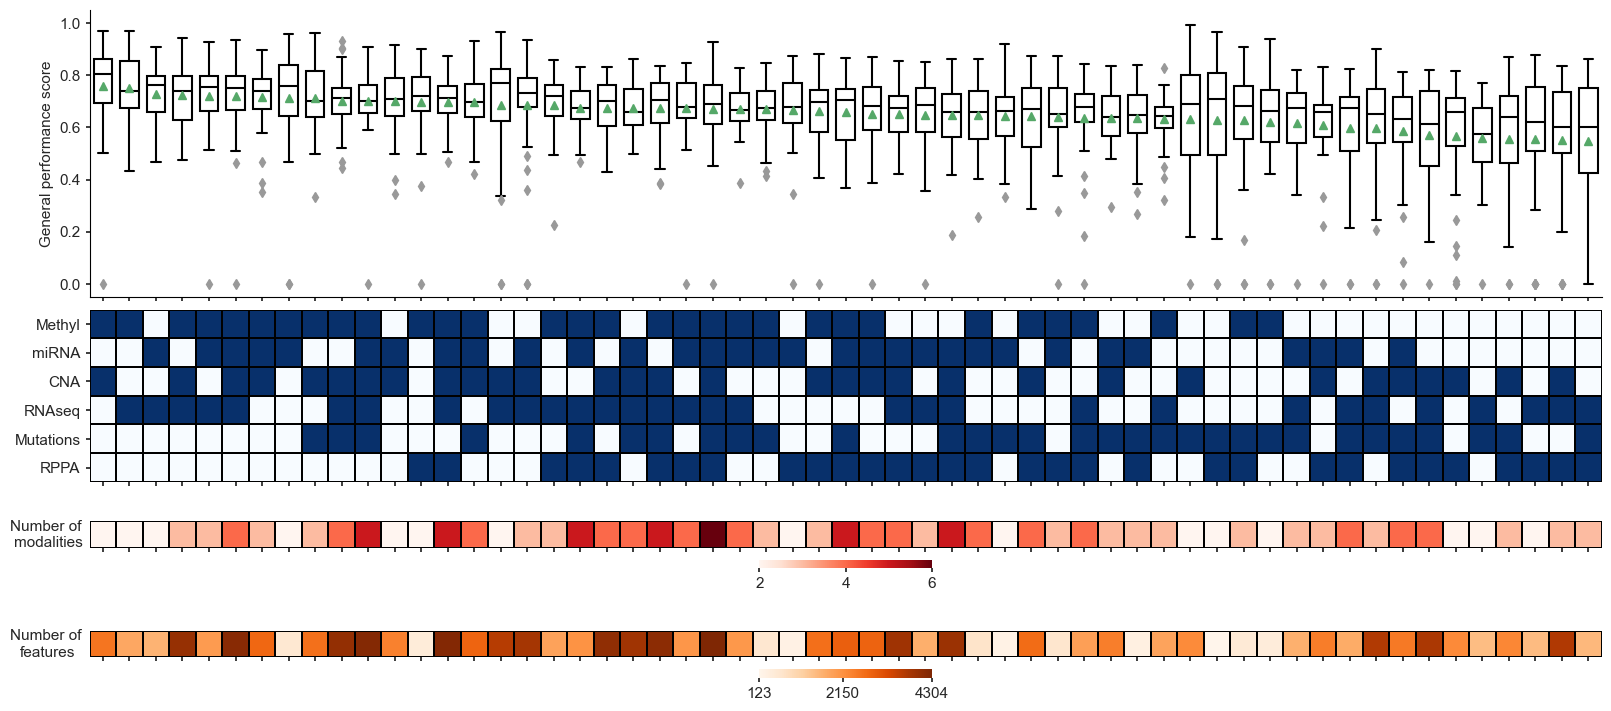

In [8]:
metric = 'combined_metric'
views = ['CNA', 'Methyl', 'Mutations', 'RNAseq', 'RPPA', 'miRNA']

combinations_average = results1.groupby(['view_combination']).mean(numeric_only=True).sort_values(by=metric, ascending=False)
combinations_sorted = combinations_average.index.tolist()

fig, ax = plt.subplots(4, 1, sharex=True, figsize=(16,7), height_ratios=[0.5, 0.3, 0.1, 0.1])

# First plot: boxplots with combined metric score for each combination
sns.boxplot(data=results1, x='view_combination', y=metric, ax=ax[0], 
            order=combinations_sorted, width=0.7, color='white', showmeans=True)
ax[0].set_ylabel('General performance score')
ax[0].set_xlabel('')
ax[0].set_axisbelow(True)
ax[0].set_ylim(-0.05, 1.05)
for line in ax[0].lines:
    line.set_color('black')
    line.set_xdata(line.get_xdata() + 0.5)
for patch in ax[0].patches:
    patch.set_edgecolor('black')
    vertices = patch.get_path().vertices
    vertices[:, 0] += 0.5

# Second plot: heatmap showing modalities present 
views_matrix = combinations_average.reset_index()
views_matrix_expanded = views_matrix['view_combination'].apply(lambda x: pd.Series(list(x))).astype(int)
views_matrix_expanded.columns = views
views_matrix_expanded.index = views_matrix['view_combination']
views_ordered = ['Methyl', 'miRNA', 'CNA', 'RNAseq', 'Mutations', 'RPPA'] 
# (^this is a bit of cheating, it is the order from highest to lowest of the modalities as calculated in the next step)
views_matrix_expanded = views_matrix_expanded.reindex(columns=views_ordered)
sns.heatmap(views_matrix_expanded.T, cmap='Blues', linewidths=0.1, linecolor='black', 
            cbar=False, ax=ax[1]).set(xlabel=None)
# ax[1].set_ylabel('Modalities')
ax[1].tick_params(axis='x', bottom=True, labelbottom=False)

# Third plot: heatmap showing number of modalities
unique_nviews_data = combinations_average['n_views'].to_frame()
sns.heatmap(unique_nviews_data.T, cmap='Reds', linewidths=0.1, linecolor='black', square=True,
            cbar=True, cbar_kws=dict(use_gridspec=True, location="bottom", pad=0.2), ax=ax[2], 
            yticklabels='', xticklabels=unique_nviews_data.index).set(xlabel=None)
ax[2].set_ylabel('Number of \nmodalities', labelpad=30, rotation=0, va='center')

# Fourth plot: heatmap showing number of features
features = [2185, 385, 52, 1419, 71, 192]
feature_sums = {}
for combination in combinations_sorted:
    total = sum(features[i] for i, bit in enumerate(combination) if bit == '1')
    feature_sums[combination] = total
features_df = pd.DataFrame(feature_sums, index=['number of features'])
sns.heatmap(features_df, cmap='Oranges', linewidths=0.1, linecolor='black', cbar=True, 
            cbar_kws=dict(use_gridspec=True, location="bottom", ticks=[123, 2150, 4304], pad=0.2), ax=ax[3], square=True,
            yticklabels='', xticklabels=features_df.columns).set(xlabel=None)
ax[3].set_ylabel('Number of \nfeatures', labelpad=30, rotation=0, va='center')
ax[3].set_xticklabels('')

# plt.tight_layout()
plt.savefig('FIGURES/benchmarking/best_combination_combined.svg', bbox_inches='tight')
plt.show()

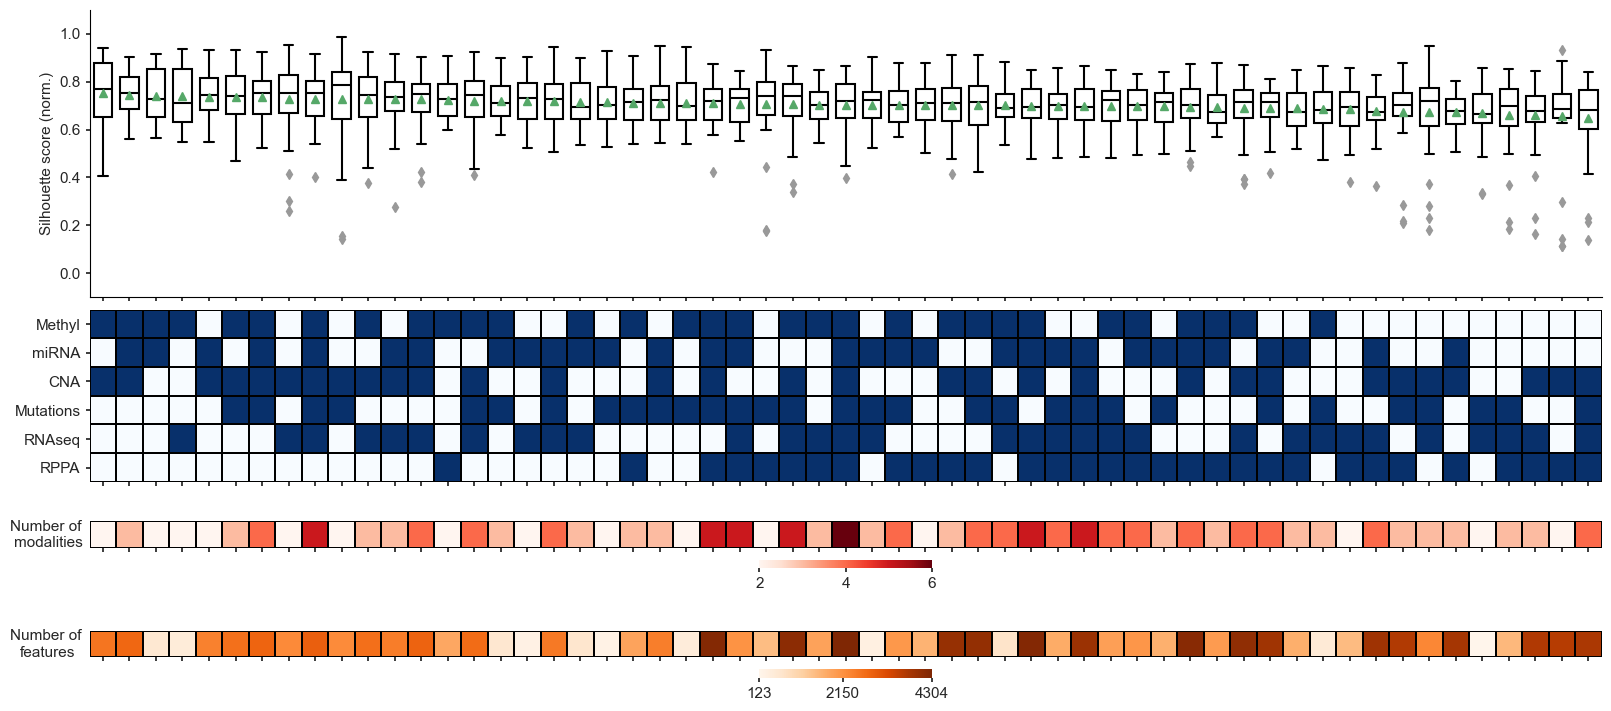

In [9]:
metric = 'normalised_silhouette'
views = ['CNA', 'Methyl', 'Mutations', 'RNAseq', 'RPPA', 'miRNA']

combinations_average = results1.groupby(['view_combination']).mean(numeric_only=True).sort_values(by=metric, ascending=False)
combinations_sorted = combinations_average.index.tolist()

fig, ax = plt.subplots(4, 1, sharex=True, figsize=(16,7), height_ratios=[0.5, 0.3, 0.1, 0.1])

# First plot: boxplots with combined metric score for each combination
sns.boxplot(data=results1, x='view_combination', y=metric, ax=ax[0], 
            order=combinations_sorted, width=0.7, color='white', showmeans=True)
ax[0].set_ylabel('Silhouette score (norm.)')
ax[0].set_xlabel('')
ax[0].set_axisbelow(True)
ax[0].set_ylim(-0.1, 1.1)
for line in ax[0].lines:
    line.set_color('black')
    line.set_xdata(line.get_xdata() + 0.5)
for patch in ax[0].patches:
    patch.set_edgecolor('black')
    vertices = patch.get_path().vertices
    vertices[:, 0] += 0.5

# Second plot: heatmap showing modalities present 
views_matrix = combinations_average.reset_index()
views_matrix_expanded = views_matrix['view_combination'].apply(lambda x: pd.Series(list(x))).astype(int)
views_matrix_expanded.columns = views
views_matrix_expanded.index = views_matrix['view_combination']
views_ordered = ['Methyl', 'miRNA', 'CNA', 'Mutations', 'RNAseq', 'RPPA'] 
# (^this is a bit of cheating, it is the order from highest to lowest of the modalities as calculated in the next step)
views_matrix_expanded = views_matrix_expanded.reindex(columns=views_ordered)
sns.heatmap(views_matrix_expanded.T, cmap='Blues', linewidths=0.1, linecolor='black', 
            cbar=False, ax=ax[1]).set(xlabel=None)
ax[1].tick_params(axis='x', bottom=True, labelbottom=False)

# Third plot: heatmap showing number of modalities
unique_nviews_data = combinations_average['n_views'].to_frame()
sns.heatmap(unique_nviews_data.T, cmap='Reds', linewidths=0.1, linecolor='black', square=True,
            cbar=True, cbar_kws=dict(use_gridspec=True, location="bottom", pad=0.2), ax=ax[2], 
            yticklabels='', xticklabels=unique_nviews_data.index).set(xlabel=None)
ax[2].set_ylabel('Number of \nmodalities', labelpad=30, rotation=0, va='center')

# Fourth plot: heatmap showing number of features
features = [2185, 385, 52, 71, 1419, 192]
feature_sums = {}
for combination in combinations_sorted:
    total = sum(features[i] for i, bit in enumerate(combination) if bit == '1')
    feature_sums[combination] = total
features_df = pd.DataFrame(feature_sums, index=['number of features'])
sns.heatmap(features_df, cmap='Oranges', linewidths=0.1, linecolor='black', cbar=True, 
            cbar_kws=dict(use_gridspec=True, location="bottom", ticks=[123, 2150, 4304], pad=0.2), ax=ax[3], square=True,
            yticklabels='', xticklabels=features_df.columns).set(xlabel=None)
ax[3].set_ylabel('Number of \nfeatures', labelpad=30, rotation=0, va='center')
ax[3].set_xticklabels('')

# plt.tight_layout()
plt.savefig('FIGURES/benchmarking/best_combination_silhouette.svg', bbox_inches='tight')
plt.show()

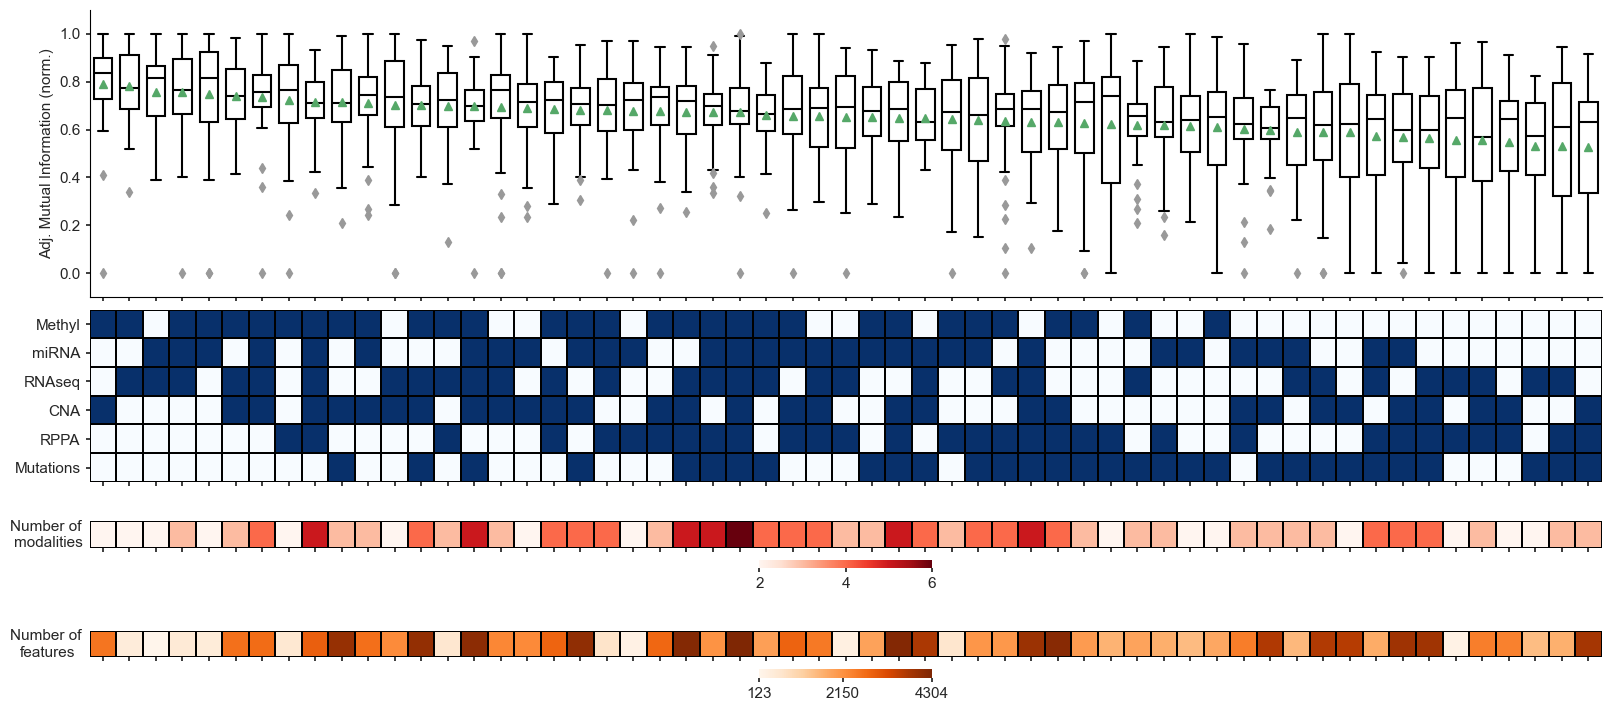

In [10]:
metric = 'normalised_AMI'
views = ['CNA', 'Methyl', 'Mutations', 'RNAseq', 'RPPA', 'miRNA']

combinations_average = results1.groupby(['view_combination']).mean(numeric_only=True).sort_values(by=metric, ascending=False)
combinations_sorted = combinations_average.index.tolist()

fig, ax = plt.subplots(4, 1, sharex=True, figsize=(16,7), height_ratios=[0.5, 0.3, 0.1, 0.1])

# First plot: boxplots with combined metric score for each combination
sns.boxplot(data=results1, x='view_combination', y=metric, ax=ax[0], 
            order=combinations_sorted, width=0.7, color='white', showmeans=True)
ax[0].set_ylabel('Adj. Mutual Information (norm.)')
ax[0].set_xlabel('')
ax[0].set_axisbelow(True)
ax[0].set_ylim(-0.1, 1.1)
for line in ax[0].lines:
    line.set_color('black')
    line.set_xdata(line.get_xdata() + 0.5)
for patch in ax[0].patches:
    patch.set_edgecolor('black')
    vertices = patch.get_path().vertices
    vertices[:, 0] += 0.5

# Second plot: heatmap showing modalities present 
views_matrix = combinations_average.reset_index()
views_matrix_expanded = views_matrix['view_combination'].apply(lambda x: pd.Series(list(x))).astype(int)
views_matrix_expanded.columns = views
views_matrix_expanded.index = views_matrix['view_combination']
views_ordered = ['Methyl', 'miRNA', 'RNAseq', 'CNA', 'RPPA', 'Mutations'] 
# (^this is a bit of cheating, it is the order from highest to lowest of the modalities as calculated in the next step)
views_matrix_expanded = views_matrix_expanded.reindex(columns=views_ordered)
sns.heatmap(views_matrix_expanded.T, cmap='Blues', linewidths=0.1, linecolor='black', 
            cbar=False, ax=ax[1]).set(xlabel=None)
ax[1].tick_params(axis='x', bottom=True, labelbottom=False)

# Third plot: heatmap showing number of modalities
unique_nviews_data = combinations_average['n_views'].to_frame()
sns.heatmap(unique_nviews_data.T, cmap='Reds', linewidths=0.1, linecolor='black', square=True,
            cbar=True, cbar_kws=dict(use_gridspec=True, location="bottom", pad=0.2), ax=ax[2], 
            yticklabels='', xticklabels=unique_nviews_data.index).set(xlabel=None)
ax[2].set_ylabel('Number of \nmodalities', labelpad=30, rotation=0, va='center')

# Fourth plot: heatmap showing number of features
features = [2185, 385, 1419, 52, 192, 71]
feature_sums = {}
for combination in combinations_sorted:
    total = sum(features[i] for i, bit in enumerate(combination) if bit == '1')
    feature_sums[combination] = total
features_df = pd.DataFrame(feature_sums, index=['number of features'])
sns.heatmap(features_df, cmap='Oranges', linewidths=0.1, linecolor='black', cbar=True, 
            cbar_kws=dict(use_gridspec=True, location="bottom", ticks=[123, 2150, 4304], pad=0.2), ax=ax[3], square=True,
            yticklabels='', xticklabels=features_df.columns).set(xlabel=None)
ax[3].set_ylabel('Number of \nfeatures', labelpad=30, rotation=0, va='center')
ax[3].set_xticklabels('')

# plt.tight_layout()
plt.savefig('FIGURES/benchmarking/best_combination_AMI.svg', bbox_inches='tight')
plt.show()

### Raincloud plots

In [11]:
# Function to plot boxplots for a specific variable
def raincloud_plots_variables(df, column_name, metric_name, ax, ylabel):
    mean_values = df.groupby(column_name)[metric_name].mean().sort_values(ascending=False)
    sorted_categories = mean_values.index.tolist()
    metric_subsets = [df[df[column_name] == cat][metric_name].values for cat in sorted_categories]
    pt.RainCloud(x=column_name, y=metric_name, data=df, bw=0.2, palette=[colorblind_palette[0]],
                 width_viol=0.4, ax=ax, orient="v", move=0.2, order=sorted_categories, alpha=0.8)
    means = df.groupby(column_name)[metric_name].mean().loc[sorted_categories]
    sns.scatterplot(x=range(len(sorted_categories)), y=means.values, ax=ax, color=colorblind_palette[2], s=100, marker='^', zorder=10)
    ax.set_xticks(range(len(sorted_categories)))
    ax.set_xticklabels(sorted_categories)
    ax.set_ylabel(ylabel)
    ax.set_ylim(-0.05, 1.05)
    ax.set_axisbelow(True)
    pvalue = kruskal(*metric_subsets).pvalue
    if pvalue >= 0.001:
        pvalue_text = f"Kruskal-Wallis, p = {pvalue:.3f}"
    else:
        pvalue_text = f"Kruskal-Wallis, p = {pvalue:.2e}"
    return pvalue, pvalue_text

In [12]:
normalised_silhouette1_alg = add_normalised_metric(results_clin1, variable_to_normalise='algorithm', metric='silhouette', greater_is_better=True)
stability_metrics_results1_alg = calculate_stability_metrics(normalised_silhouette1_alg, random_state=42, progress_bar=True)
stability_metrics_results1_alg[['AMI', 'ARI']] = stability_metrics_results1_alg[['AMI','ARI']].fillna(value=0)
stability_metrics_results1_alg[['AMI', 'ARI']] = stability_metrics_results1_alg[['AMI', 'ARI']].clip(lower=0)
normalised_ami1_alg = add_normalised_metric(stability_metrics_results1_alg, variable_to_normalise='algorithm', metric='AMI', greater_is_better=True)
results1_alg = normalised_ami1_alg.copy()
results1_alg['n_views'] = results1_alg['view_combination'].str.count('1')
results1_alg['combined_metric'] = results1_alg[['normalised_silhouette', 'normalised_AMI']].mean(axis=1)
results1_alg.sort_values('combined_metric', ascending=False, inplace=True)
results1_alg

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [03:15<00:00, 195.94s/it]


,dataset,algorithm,missing_percentage,amputation_mechanism,view_combination,n_clusters,silhouette,vrc,db,dbcv,...,rsi,bhi,normalised_silhouette,pvalue_logrank,n_enriched_clinical,AMI,ARI,normalised_AMI,n_views,combined_metric
1410,TCGA_PDAC_subset,NEMO,0,No,100100,2,0.784891,380.902491,0.337556,0.641085,...,0.581944,0.072000,0.968595,0.542602,0.0,0.863964,0.916737,1.000000,2,0.984297
1478,TCGA_PDAC_subset,NEMO,0,No,110101,2,0.718600,264.841215,0.392937,0.684654,...,0.525107,0.102241,0.966681,0.388183,0.0,0.951159,0.972734,1.000000,4,0.983340
1303,TCGA_PDAC_subset,NEMO,0,No,000101,2,0.655367,246.304119,0.453922,0.726245,...,0.559656,0.120052,0.963980,0.407945,0.1,0.691181,0.742873,1.000000,2,0.981990
530,TCGA_PDAC_subset,IMSR,0,No,101001,2,0.728073,277.847587,0.385527,0.671635,...,0.519409,0.101440,0.961560,0.677344,0.0,0.664869,0.736484,1.000000,3,0.980780
499,TCGA_PDAC_subset,IMSR,0,No,100001,2,0.713929,220.730073,0.469855,0.687904,...,0.356234,0.120323,0.961518,0.795849,0.0,0.805416,0.847180,1.000000,2,0.980759
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10,TCGA_PDAC_subset,DFMF,0,No,001010,3,0.102631,10.395929,1.978191,0.972414,...,-1.274637,191.825939,0.185390,0.346880,0.0,0.000000,0.000000,0.000000,2,0.092695
90,TCGA_PDAC_subset,DFMF,0,No,100110,5,0.068968,15.188766,2.047086,0.978221,...,-1.616490,73.113127,0.166336,0.640866,0.0,0.000000,0.000000,0.000000,3,0.083168
96,TCGA_PDAC_subset,DFMF,0,No,101000,5,0.059278,8.869989,2.084209,0.979246,...,-2.662426,89.076724,0.129763,0.122370,0.0,0.000000,0.000000,0.000000,2,0.064882
77,TCGA_PDAC_subset,DFMF,0,No,100010,4,0.056172,6.108206,2.699458,0.978215,...,-2.396194,137.508708,0.113362,0.606988,0.0,0.004536,0.007558,0.007526,2,0.060444


In [13]:
normalised_silhouette1_clusters = add_normalised_metric(results_clin1, variable_to_normalise='n_clusters', metric='silhouette', greater_is_better=True)
stability_metrics_results1_clusters = calculate_stability_metrics(normalised_silhouette1_clusters, random_state=42, progress_bar=True)
stability_metrics_results1_clusters[['AMI', 'ARI']] = stability_metrics_results1_clusters[['AMI','ARI']].fillna(value=0)
stability_metrics_results1_clusters[['AMI', 'ARI']] = stability_metrics_results1_clusters[['AMI', 'ARI']].clip(lower=0)
normalised_ami1_clusters = add_normalised_metric(stability_metrics_results1_clusters, variable_to_normalise='n_clusters', metric='AMI', greater_is_better=True)
results1_clusters = normalised_ami1_clusters.copy()
results1_clusters['n_views'] = results1_clusters['view_combination'].str.count('1')
results1_clusters["normalised_AMI"] = results1_clusters["normalised_AMI"].fillna(value=0)
results1_clusters['combined_metric'] = results1_clusters[['normalised_silhouette', 'normalised_AMI']].mean(axis=1)
results1_clusters.sort_values('combined_metric', ascending=False, inplace=True)
results1_clusters

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [03:12<00:00, 192.68s/it]


,dataset,algorithm,missing_percentage,amputation_mechanism,view_combination,n_clusters,silhouette,vrc,db,dbcv,...,rsi,bhi,normalised_silhouette,pvalue_logrank,n_enriched_clinical,AMI,ARI,normalised_AMI,n_views,combined_metric
463,TCGA_PDAC_subset,IMSR,0,No,010111,2,0.628124,212.795607,0.485507,0.730896,...,0.500175,0.122745,0.988415,0.708580,0.0,0.777689,0.824065,1.000000,4,0.994208
1207,TCGA_PDAC_subset,MOFA,0,No,101000,2,0.618971,81.072165,0.618903,0.691370,...,0.100611,32.661529,0.984457,0.472150,0.0,1.000000,1.000000,1.000000,2,0.992228
586,TCGA_PDAC_subset,IMSR,0,No,110111,2,0.637853,226.375940,0.470212,0.729521,...,0.531317,0.117167,0.983898,0.646504,0.0,0.817277,0.873367,1.000000,5,0.991949
614,TCGA_PDAC_subset,IMSR,0,No,111110,2,0.629486,214.550230,0.486781,0.735189,...,0.512016,0.122220,0.983081,0.616912,0.0,0.750189,0.800153,1.000000,5,0.991541
602,TCGA_PDAC_subset,IMSR,0,No,111011,2,0.628794,214.645907,0.486871,0.735117,...,0.511317,0.122179,0.981975,0.613354,0.0,0.748062,0.804328,1.000000,5,0.990987
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,TCGA_PDAC_subset,DFMF,0,No,100010,4,0.056172,6.108206,2.699458,0.978215,...,-2.396194,137.508708,0.219563,0.606988,0.0,0.004536,0.007558,0.039473,2,0.129518
96,TCGA_PDAC_subset,DFMF,0,No,101000,5,0.059278,8.869989,2.084209,0.979246,...,-2.662426,89.076724,0.209990,0.122370,0.0,0.000000,0.000000,0.000000,2,0.104995
10,TCGA_PDAC_subset,DFMF,0,No,001010,3,0.102631,10.395929,1.978191,0.972414,...,-1.274637,191.825939,0.204810,0.346880,0.0,0.000000,0.000000,0.000000,2,0.102405
90,TCGA_PDAC_subset,DFMF,0,No,100110,5,0.068968,15.188766,2.047086,0.978221,...,-1.616490,73.113127,0.193155,0.640866,0.0,0.000000,0.000000,0.000000,3,0.096577


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


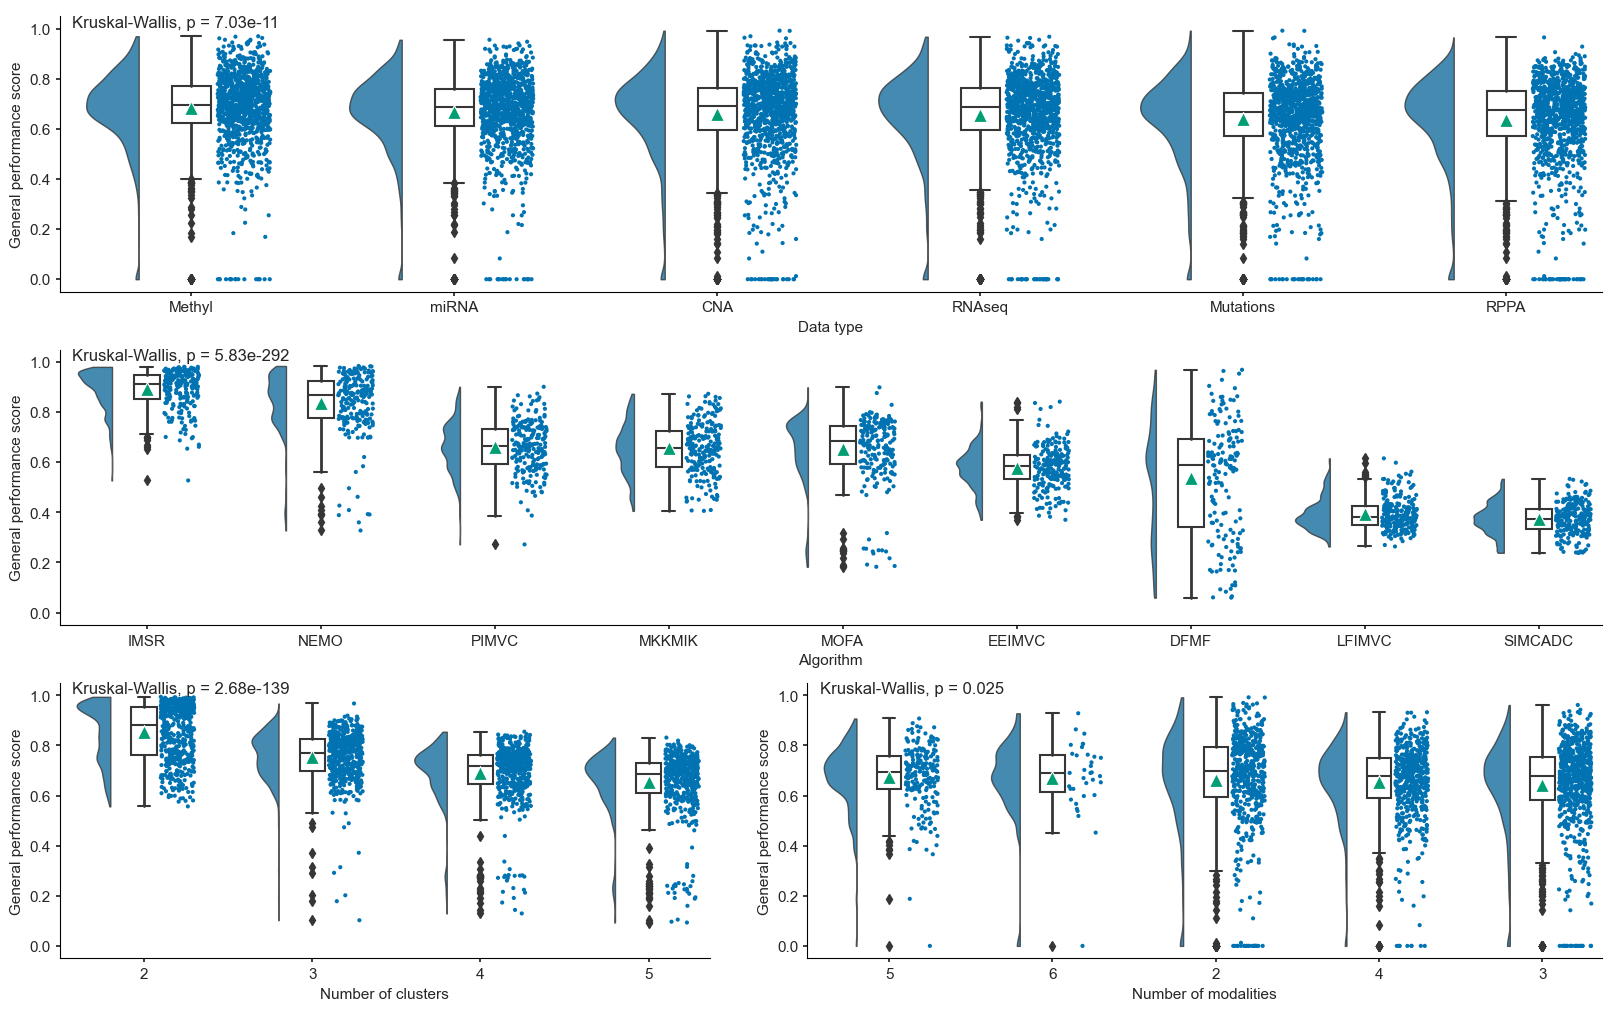

In [14]:
metric='combined_metric'
ylabel='General performance score'
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1], width_ratios=[0.45, 0.55])

# plot for combinations containing each data type
ax1 = fig.add_subplot(gs[0, :])
plot_data = []
views = ['CNA', 'Methyl', 'Mutations', 'RNAseq', 'RPPA', 'miRNA']
for i, view in enumerate(views):
    subset = results1[results1['view_combination'].str[i] == '1']
    subset['data_type'] = view
    plot_data.append(subset)
combined_df = pd.concat(plot_data)
pvalue, pvalue_text = raincloud_plots_variables(combined_df, 'data_type', metric, ax1, ylabel)
ax1.set_xlabel('Data type')
ax1.legend(title=f"{pvalue_text}", loc=2, bbox_to_anchor=(0, 1.05))

# plot for algorithm
ax2 = fig.add_subplot(gs[1, :])
pvalue, pvalue_text = raincloud_plots_variables(results1_alg, 'algorithm', metric, ax2, ylabel)
ax2.set_xlabel('Algorithm')
ax2.legend(title=f"{pvalue_text}", loc=2, bbox_to_anchor=(0, 1.05))

# plot for number of clusters
ax3 = fig.add_subplot(gs[2, 0])
pvalue, pvalue_text = raincloud_plots_variables(results1_clusters, 'n_clusters', metric, ax3, ylabel)
ax3.set_xlabel('Number of clusters')
ax3.legend(title=f"{pvalue_text}", loc=2, bbox_to_anchor=(0, 1.05))

# plot for combinations with a specific number of views
ax4 = fig.add_subplot(gs[2, 1])
pvalue, pvalue_text = raincloud_plots_variables(results1, 'n_views', metric, ax4, ylabel)
ax4.set_xlabel('Number of modalities')
ax4.legend(title=f"{pvalue_text}", loc=2, bbox_to_anchor=(0, 1.05)).set_zorder(100)

fig.subplots_adjust(wspace = 0.3, hspace = 0.4)
plt.savefig('FIGURES/benchmarking/raincloud_plots_combined.svg', bbox_inches='tight')
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


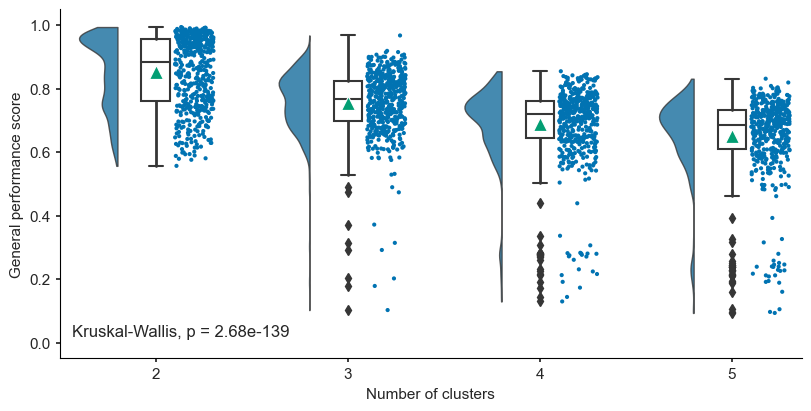

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
pvalue, pvalue_text = raincloud_plots_variables(results1_clusters, 'n_clusters', metric, ax, ylabel)
ax.set_xlabel('Number of clusters')
ax.legend(title=f"{pvalue_text}", loc=3, bbox_to_anchor=(0, 0))
plt.savefig('FIGURES/benchmarking/rainclouds_clusters.svg', bbox_inches='tight')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


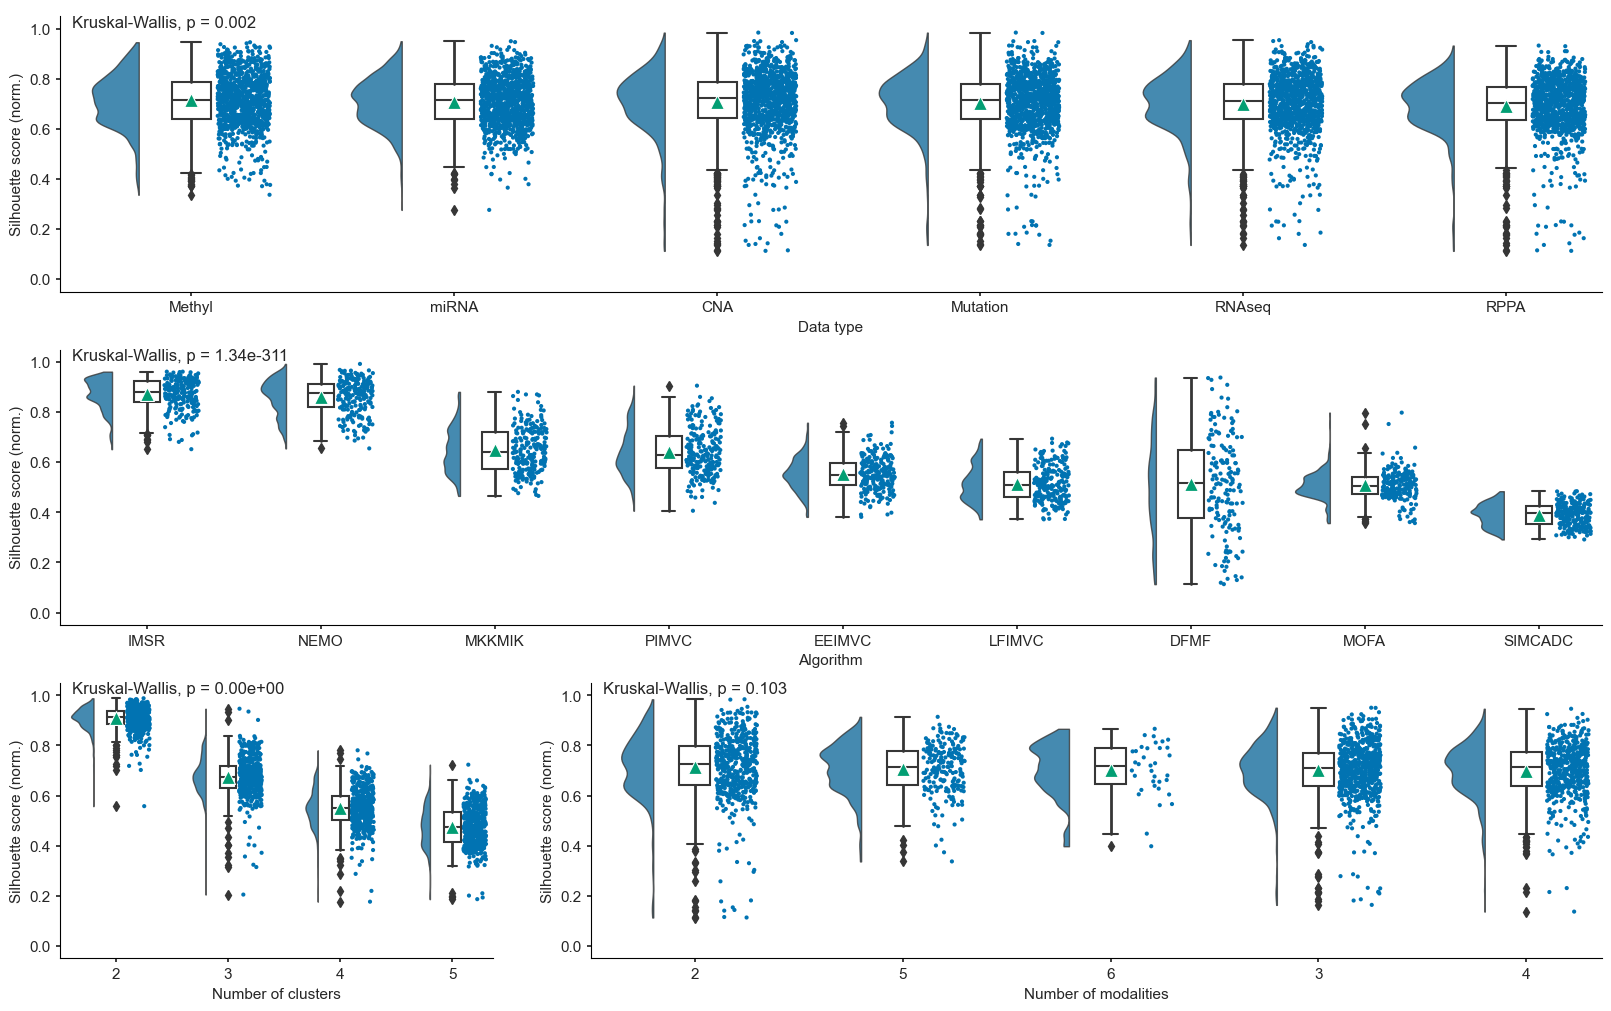

In [16]:
metric='normalised_silhouette'
ylabel='Silhouette score (norm.)'
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1], width_ratios=[0.3, 0.7])

# plot for combinations containing each data type
ax1 = fig.add_subplot(gs[0, :])
plot_data = []
views = ['CNA', 'Methyl', 'Mutation', 'RNAseq', 'RPPA', 'miRNA']
for i, view in enumerate(views):
    subset = results1[results1['view_combination'].str[i] == '1']
    subset['data_type'] = view
    plot_data.append(subset)
combined_df = pd.concat(plot_data)
pvalue, pvalue_text = raincloud_plots_variables(combined_df, 'data_type', metric, ax1, ylabel)
ax1.set_xlabel('Data type')
ax1.legend(title=f"{pvalue_text}", loc=2, bbox_to_anchor=(0, 1.05))

# plot for algorithm
ax2 = fig.add_subplot(gs[1, :])
pvalue, pvalue_text = raincloud_plots_variables(results1_alg, 'algorithm', metric, ax2, ylabel)
ax2.set_xlabel('Algorithm')
ax2.legend(title=f"{pvalue_text}", loc=2, bbox_to_anchor=(0, 1.05))

# plot for number of clusters
ax3 = fig.add_subplot(gs[2, 0])
pvalue, pvalue_text = raincloud_plots_variables(results1_clusters, 'n_clusters', metric, ax3, ylabel)
ax3.set_xlabel('Number of clusters')
ax3.legend(title=f"{pvalue_text}", loc=2, bbox_to_anchor=(0, 1.05))

# plot for combinations with a specific number of views
ax4 = fig.add_subplot(gs[2, 1])
pvalue, pvalue_text = raincloud_plots_variables(results1, 'n_views', metric, ax4, ylabel)
ax4.set_xlabel('Number of modalities')
ax4.legend(title=f"{pvalue_text}", loc=2, bbox_to_anchor=(0, 1.05))

fig.subplots_adjust(wspace = 0.3, hspace = 0.4)
plt.savefig('FIGURES/benchmarking/raincloud_plots_silhouette.svg', bbox_inches='tight')
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


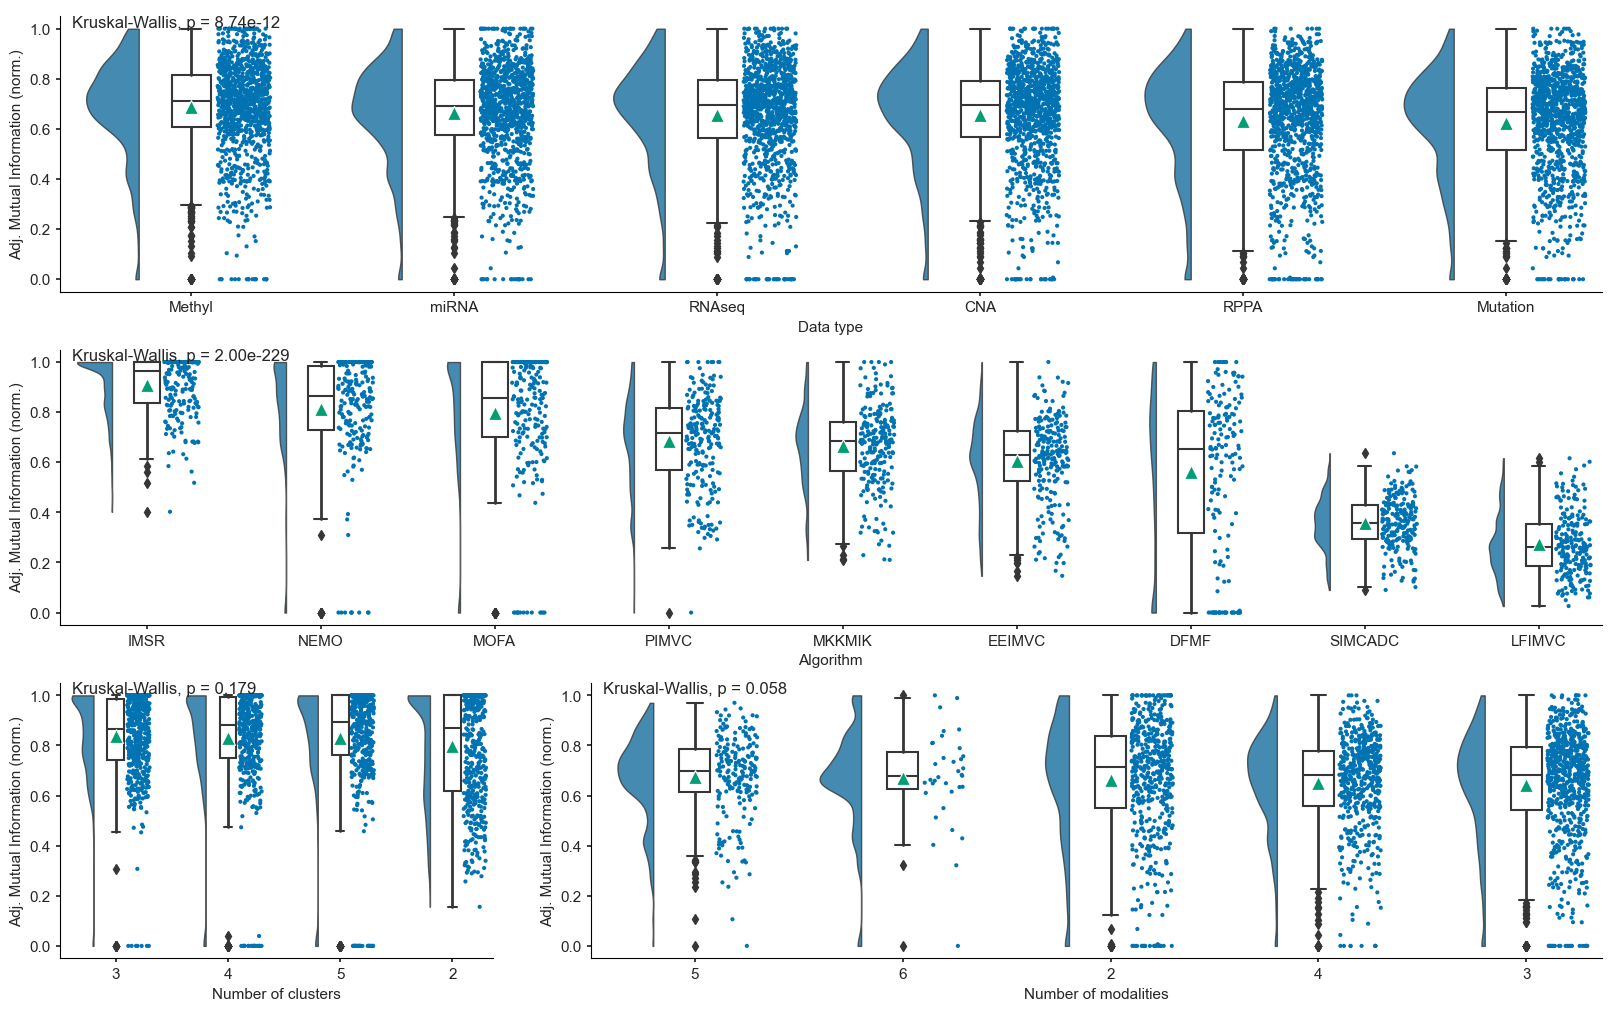

In [17]:
metric='normalised_AMI'
ylabel='Adj. Mutual Information (norm.)'
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1], width_ratios=[0.3, 0.7])

# plot for combinations containing each data type
ax1 = fig.add_subplot(gs[0, :])
plot_data = []
views = ['CNA', 'Methyl', 'Mutation', 'RNAseq', 'RPPA', 'miRNA']
for i, view in enumerate(views):
    subset = results1[results1['view_combination'].str[i] == '1']
    subset['data_type'] = view
    plot_data.append(subset)
combined_df = pd.concat(plot_data)
pvalue, pvalue_text = raincloud_plots_variables(combined_df, 'data_type', metric, ax1, ylabel)
ax1.set_xlabel('Data type')
ax1.legend(title=f"{pvalue_text}", loc=2, bbox_to_anchor=(0, 1.05)).set_zorder(100)

# plot for algorithm
ax2 = fig.add_subplot(gs[1, :])
pvalue, pvalue_text = raincloud_plots_variables(results1_alg, 'algorithm', metric, ax2, ylabel)
ax2.set_xlabel('Algorithm')
ax2.legend(title=f"{pvalue_text}", loc=2, bbox_to_anchor=(0, 1.05))

# plot for number of clusters
ax3 = fig.add_subplot(gs[2, 0])
pvalue, pvalue_text = raincloud_plots_variables(results1_clusters, 'n_clusters', metric, ax3, ylabel)
ax3.set_xlabel('Number of clusters')
ax3.legend(title=f"{pvalue_text}", loc=2, bbox_to_anchor=(0, 1.05))

# plot for combinations with a specific number of views
ax4 = fig.add_subplot(gs[2, 1])
pvalue, pvalue_text = raincloud_plots_variables(results1, 'n_views', metric, ax4, ylabel)
ax4.set_xlabel('Number of modalities')
ax4.legend(title=f"{pvalue_text}", loc=2, bbox_to_anchor=(0, 1.05)).set_zorder(100)

fig.subplots_adjust(wspace = 0.3, hspace = 0.3)
plt.savefig('FIGURES/benchmarking/raincloud_plots_AMI.svg', bbox_inches='tight')
plt.show()

### Scatter plots

In [ ]:
# Function to create new df for data types used
views = ['CNA', 'Methyl', 'Mutation', 'RNAseq', 'RPPA', 'miRNA']
def expand_views(df):
    expanded_rows = []
    for idx, row in df.iterrows():
        view_combination = row['view_combination']
        for i, bit in enumerate(view_combination):
            if bit == '1':
                new_row = row.copy()
                new_row['views_present'] = views[i]
                expanded_rows.append(new_row)
    expanded_df = pd.DataFrame(expanded_rows)
    return expanded_df

# Scatter plots (mean number of clinically enriched parameters)
def plot_scatterplot(df, column_name, ax):
    summarised_by_variable = df.groupby(column_name, as_index=False).mean(numeric_only=True)
    sns.scatterplot(x='pvalue_logrank', y='n_enriched_clinical', data = summarised_by_variable,
                    hue=column_name, style=column_name, palette = "colorblind", markers=True, s=400, ax=ax, zorder=3)
    ax.set_ylim(-0.05, 1)
    ax.set_ylabel('Mean no. significant clinical parameters')
    ax.set_xlabel('Log-rank test p-value')
    
fig, ax = plt.subplots(1, 4, figsize=(20, 4), sharey=True)
fig.subplots_adjust(wspace = 0.2, hspace = 0.2)
results1_alg_exp = expand_views(results1_alg)
plot_scatterplot(results1_alg_exp, 'algorithm', ax[0])
ax[0].legend(title='Algorithm')
results1_clusters_exp = expand_views(results1_clusters)
plot_scatterplot(results1_clusters_exp, 'n_clusters', ax[1])
ax[1].legend(title='Number\nof clusters')
results1_exp = expand_views(results1)
plot_scatterplot(results1_exp, 'n_views', ax[2])
ax[2].legend(title='Number of \nmodalities')
plot_scatterplot(results1_exp, 'views_present', ax[3])
ax[3].legend(title='Modalities present')

fig.subplots_adjust(wspace = 0.1)
# plt.savefig('figures/first_bench_figures/clinical_enrichment.svg', bbox_inches='tight')
plt.show()